In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath("/Users/charles/Documents/PhD/Analysis/ieeg-pipeline")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from analysis.decoding.config import *
from analysis.decoding.core_classes.loader import GroupLoader
from analysis.decoding.core_classes.process_features import Features
from tqdm import tqdm
import nilearn.datasets
from nibabel.affines import apply_affine

mni_tmp = nilearn.datasets.load_mni152_template()
plt.style.use('seaborn-v0_8-poster') 


In [2]:
tmin = -1.5
tmax = 1.5
subjects = [2, 3, 4, 5, 9, 12, 14, 16]
group = GroupLoader(subjects, tmin = -1.5, tmax = 1.5)
group.load_anatomy()
group.load_behavior("hmm")



In [3]:
for var in ["choice", "fb"]:
    group.load_decoding_score(5, var, "linearsvc", "hmm", "global")
    group.load_decoding_betas(5, var, "linearsvc", "hmm", "global")

([<matplotlib.axis.XTick at 0x15e9a87d0>,
 [Text(0.0, 0, '-1.5'),
  Text(128.0, 0, '-1.0'),
  Text(256.0, 0, '-0.5'),
  Text(384.0, 0, '0.0'),
  Text(512.0, 0, '0.5'),
  Text(640.0, 0, '1.0'),
  Text(768.0, 0, '1.5')])

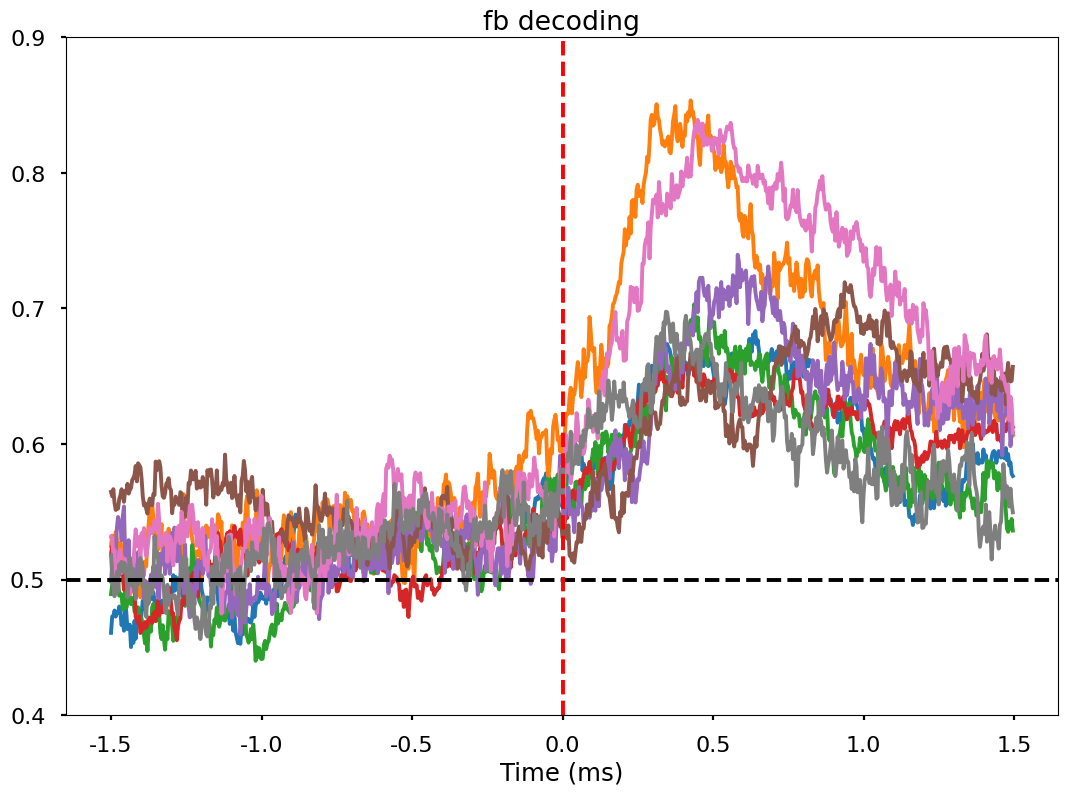

In [4]:
var = "fb"  
score_mat = group.global_score[var].T

timearray = np.linspace(tmin, tmax, int((np.abs(tmin) + tmax)*2+1))
arranged_timearray = np.arange(0, group.n_timepoints +1, group.n_timepoints/(len(timearray)-1))

plt.plot(score_mat)
plt.axhline(0.5, color='black', linestyle='--')
plt.axvline(1.5*sr_decimated, color='red', linestyle='--')
plt.title(f"{var} decoding")
plt.xlabel("Time (ms)")
plt.ylim((0.4, 0.9))
plt.xticks(ticks=arranged_timearray, labels=timearray)

([<matplotlib.axis.XTick at 0x15fe05130>,
 [Text(0.0, 0, '-1.5'),
  Text(128.0, 0, '-1.0'),
  Text(256.0, 0, '-0.5'),
  Text(384.0, 0, '0.0'),
  Text(512.0, 0, '0.5'),
  Text(640.0, 0, '1.0'),
  Text(768.0, 0, '1.5')])

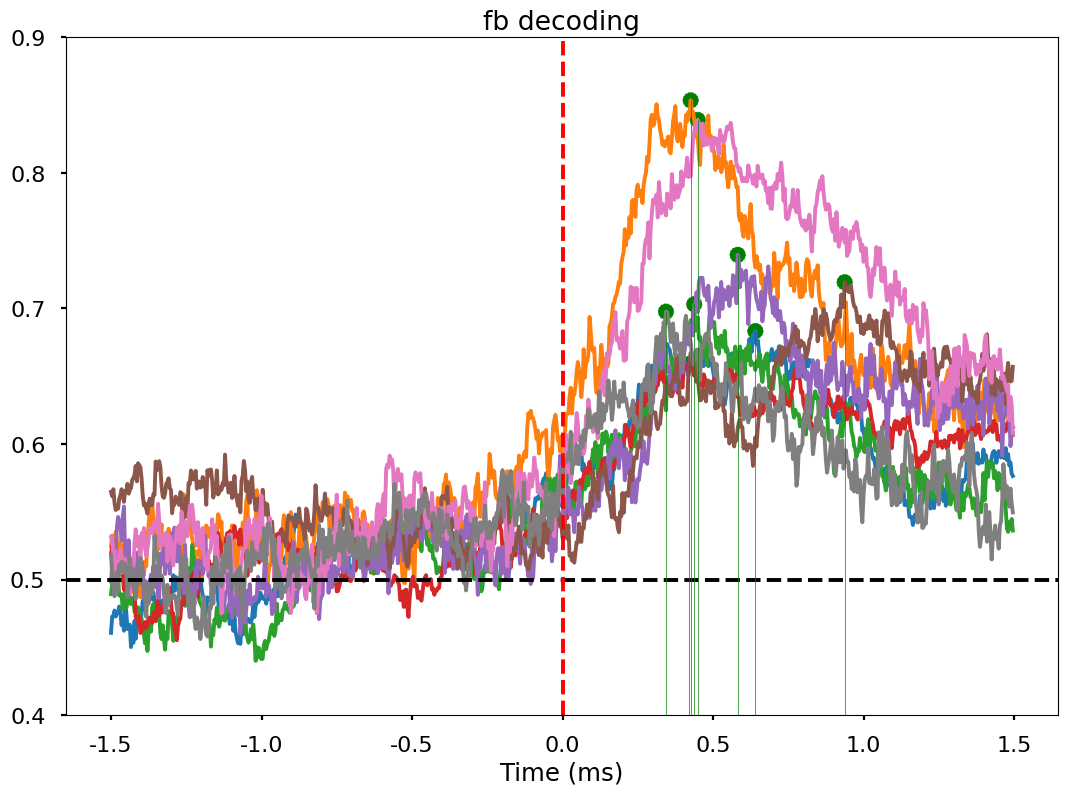

In [5]:

peak_time = np.argmax(score_mat, axis = 0)
plt.plot(score_mat)
plt.axhline(0.5, color='black', linestyle='--')
plt.axvline(1.5*sr_decimated, color='red', linestyle='--')

for i, peak in enumerate(peak_time):
    plt.scatter(peak, score_mat[peak, i], color='green', linestyle='--')
    plt.plot([peak, peak], [0.4, score_mat[peak, i]] , color='green', lw = 0.5)

plt.title(f"{var} decoding")
plt.xlabel("Time (ms)")
plt.ylim((0.4, 0.9))
plt.xticks(ticks=arranged_timearray, labels=timearray)

In [6]:
beta_mat = group.global_betas[var].T


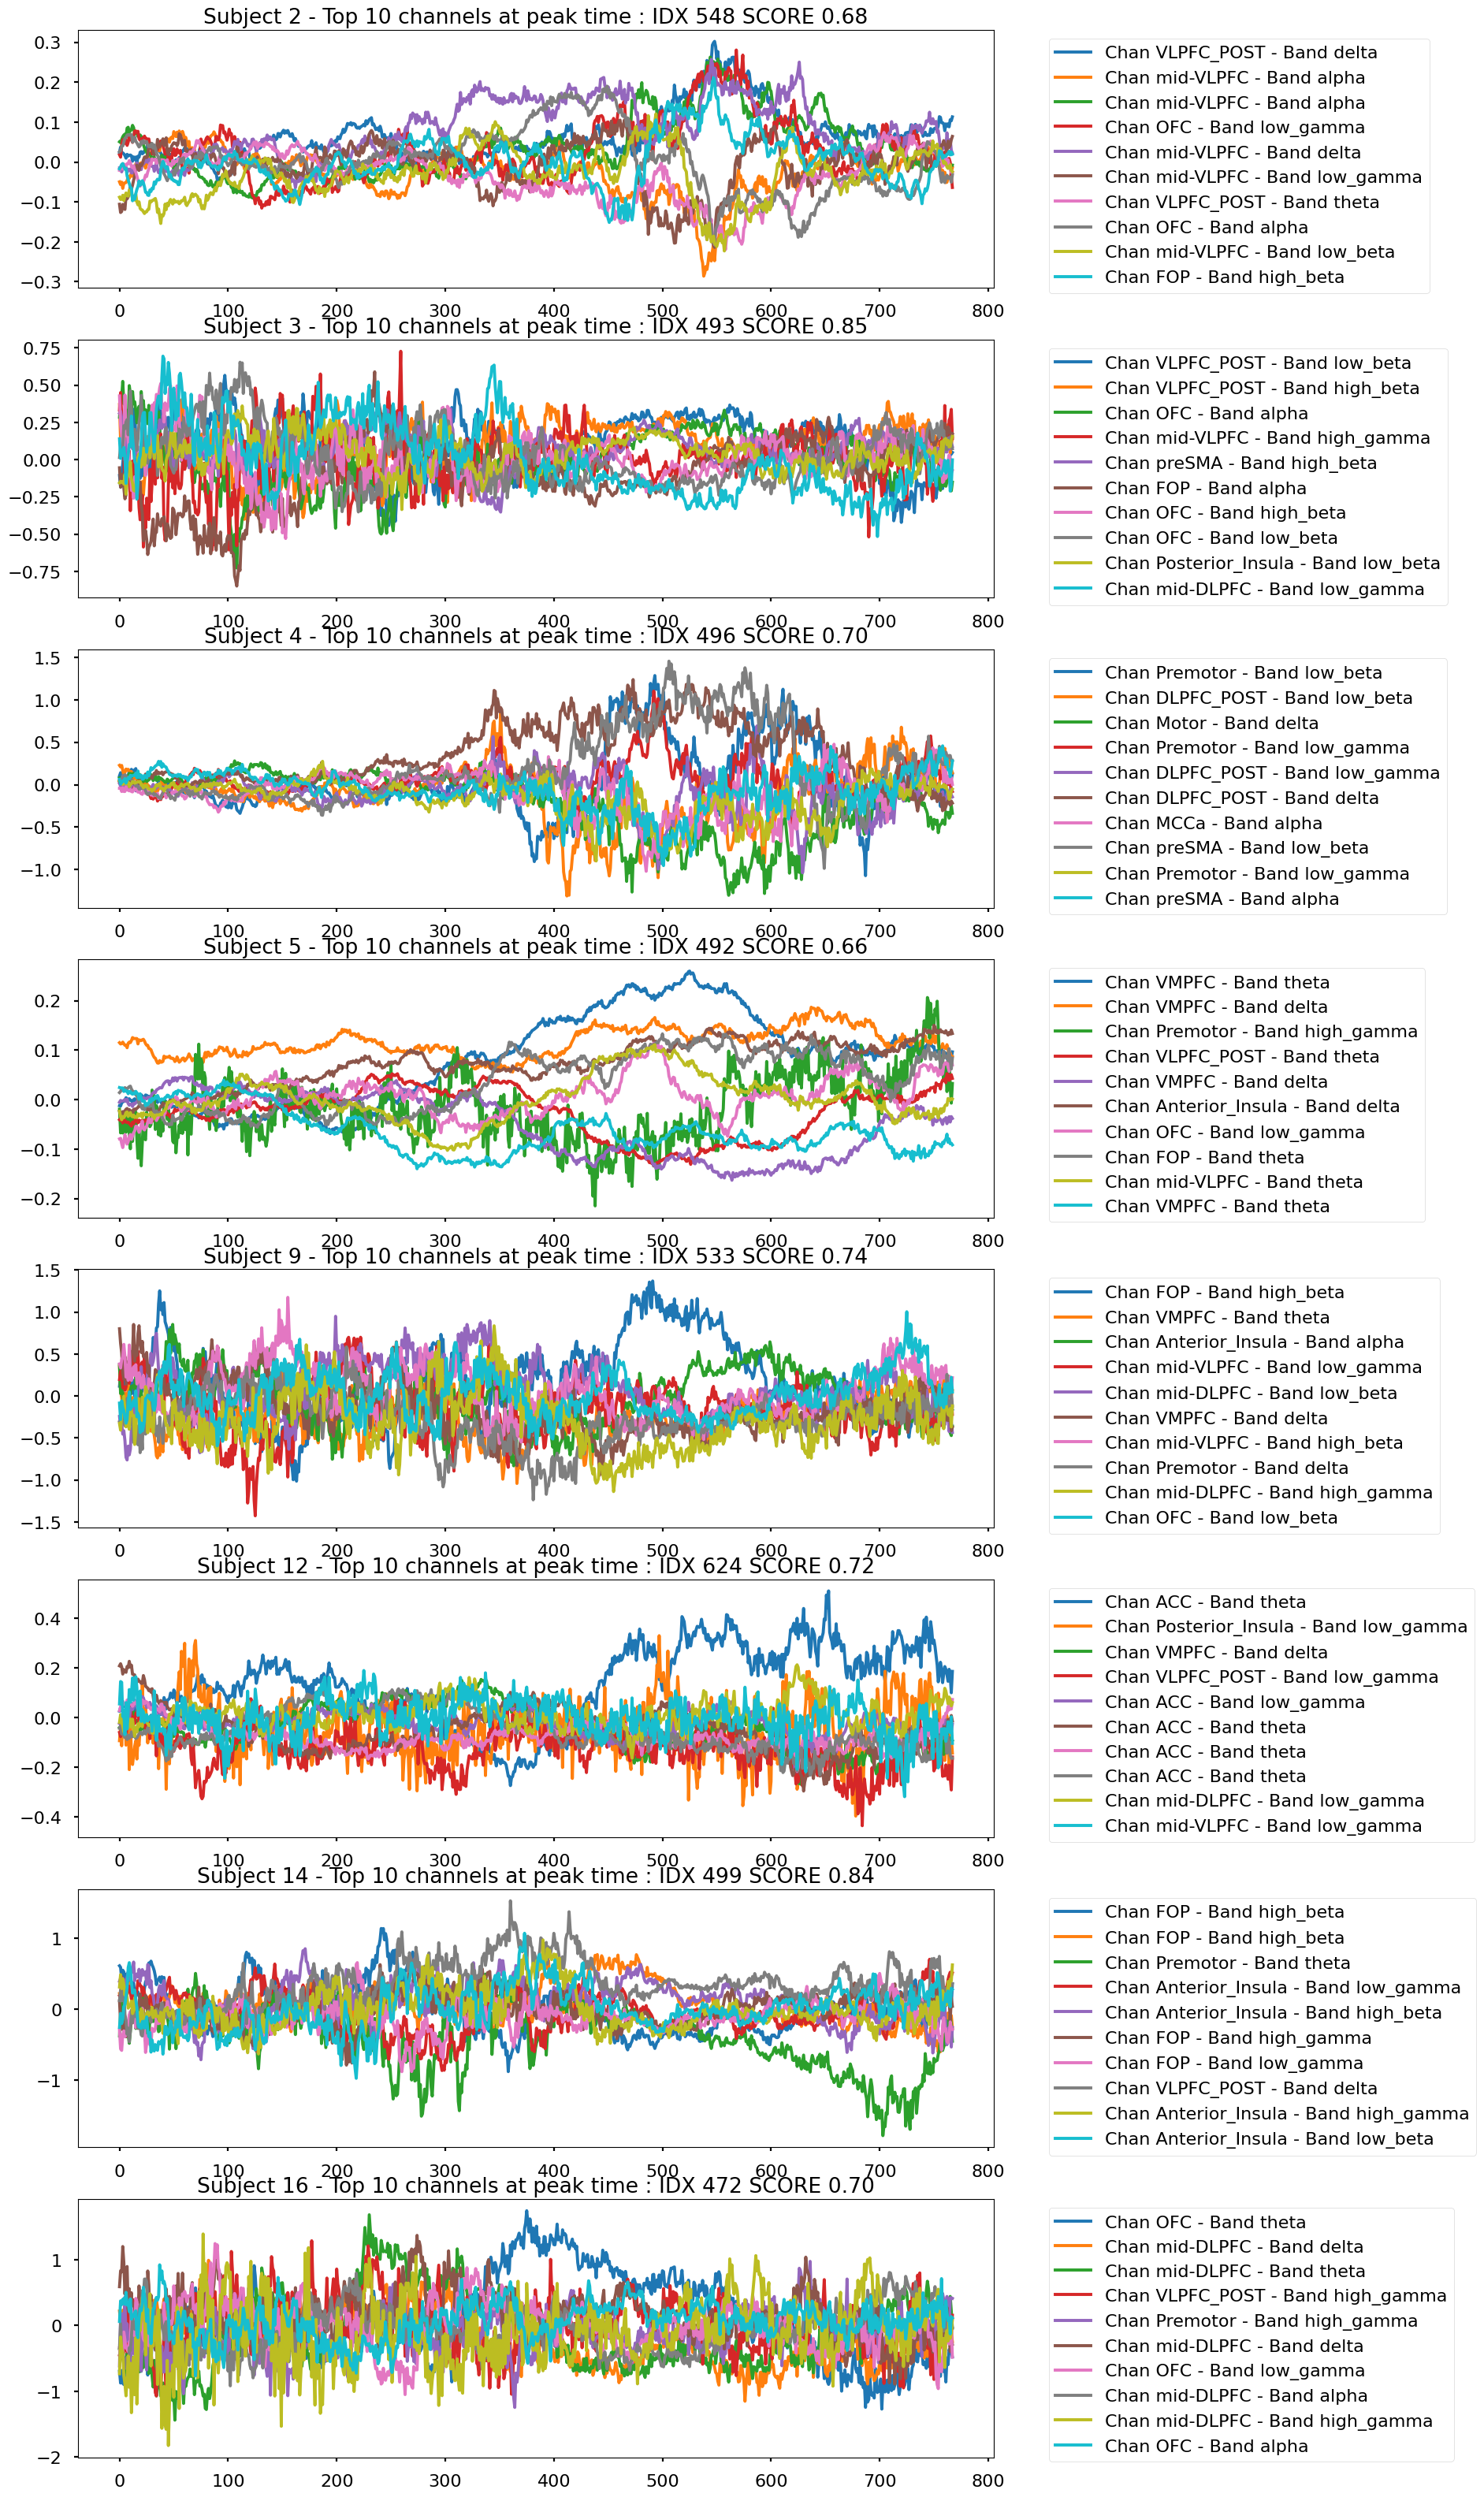

In [8]:
fig, axs = plt.subplots(len(subjects), 1, figsize = (15, 5*len(subjects)))
axs = axs.flatten()
# axs = [axs]
n_bests = 10
best_channel = []
best_band = []
for i in range(len(subjects)):
    idx_channel = group.anatomy_data.loc[group.anatomy_data['subject'] == subjects[i], "chan_idx_global"].values
    beta_best_indiv = beta_mat[:, idx_channel, peak_time[i]].T
    for j in range(1, n_bests+1) :
        idx_beta = np.argsort(np.ravel(np.abs(beta_best_indiv)))[-j]
        chan, band = np.unravel_index(idx_beta, beta_best_indiv.shape)
        best_channel.append(idx_channel[chan])
        best_band.append(band)
        axs[i].plot(beta_mat[band, best_channel[-1], :], label = f"Chan {group.anatomy_data.loc[best_channel[-1], 'region']} - Band {list(FREQUENCY_BANDS.keys())[band]}")
    axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[i].set_title(f"Subject {subjects[i]} - Top {n_bests} channels at peak time : IDX {peak_time[i]} SCORE {score_mat[peak_time[i], i]:.2f}")
    # im = axs[i].imshow(beta_best_indiv, aspect = 'auto', origin = "lower", cmap = 'jet')
    # plt.colorbar(im, ax = axs[i])

In [9]:
best_channel = np.array(best_channel).reshape(len(subjects), -1)
best_band = np.array(best_band).reshape(len(subjects), -1)


In [10]:
best_channel_df = group.anatomy_data.loc[best_channel.flatten(), :].reset_index(drop=True)
best_channel_df["best_band"] = best_band.flatten()


In [11]:
best_channel_df

,electrode,name,anode,cathode,x,y,z,is_inmask,roi_n,distances,...,cathode_is_inmask,anode_lobe,cathode_lobe,anode_distances,cathode_distances,chan_idx,subject,chan_idx_global,area_order,best_band
0,of,of8-of9,of8,of9,61.163990,19.773266,15.188396,True,74,0.000000,...,True,Fr,Fr,0.000000,2.000000,20,2,20,10,0
1,r,r8-r9,r8,r9,32.298670,42.752419,-12.375701,True,77,0.000000,...,True,Fr,Fr,1.000000,0.000000,40,2,40,9,2
2,r,r11-r12,r11,r12,44.251486,43.043671,-11.353271,True,171,0.000000,...,True,Fr,Fr,2.000000,0.000000,43,2,43,9,2
3,r,r5-r6,r5,r6,20.345856,42.461166,-13.398132,True,91,1.414214,...,True,Fr,Fr,2.236068,0.000000,37,2,37,17,5
4,r,r13-r14,r13,r14,52.220030,43.237837,-10.671650,True,171,0.000000,...,True,Fr,Fr,0.000000,1.000000,45,2,45,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,fsg,fsg6-fsg7,fsg6,fsg7,-19.053913,56.564755,29.784726,True,87,0.000000,...,True,Fr,Fr,0.000000,0.000000,13,16,390,12,0
76,ofg,ofg6-ofg7,ofg6,ofg7,-19.542729,45.831309,-11.364994,True,91,2.449490,...,True,Fr,Fr,3.316625,1.732051,38,16,415,17,5
77,fsg,fsg4-fsg5,fsg4,fsg5,-12.633487,53.233946,27.451519,True,87,2.236068,...,True,Fr,Fr,2.000000,1.000000,11,16,388,12,2
78,fsg,fsg7-fsg8,fsg7,fsg8,-22.264125,58.230158,30.951328,True,87,1.000000,...,True,Fr,Fr,0.000000,2.236068,14,16,391,12,6


In [12]:
ijk = np.round(apply_affine(np.linalg.inv(mni_tmp.affine),
                            best_channel_df[["x", "y", "z"]].to_numpy())).astype(int)
best_channel_df["i"], best_channel_df["j"], best_channel_df["k"] = ijk[:, 0], ijk[:, 1], ijk[:, 2]

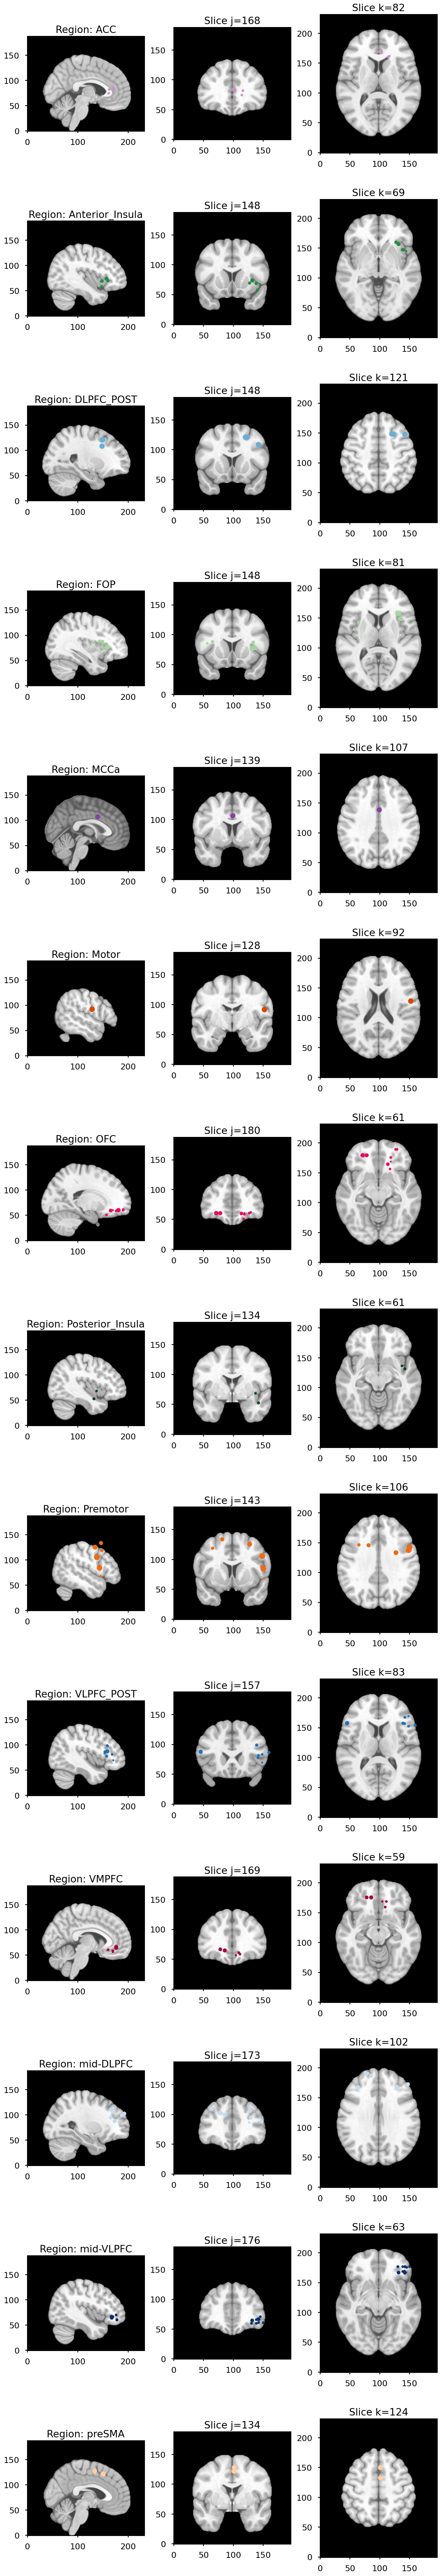

In [15]:
# i_mid = mni_tmp.shape[1]//2
# slices_idx = np.arange(mni_tmp.shape[1]//2+10, mni_tmp.shape[1]-20, (mni_tmp.shape[1]//2-30)//9)
n_region = best_channel_df["region"].unique()
nrows = len(n_region)
fig, axs = plt.subplots(nrows, 3, figsize=(12, nrows*5))
# axs = axs.flatten()
# size = 50
# for idx, row in best_channel_df.iterrows():
for i, (region, sdf) in enumerate(best_channel_df.groupby('region')):
    for j, coord in enumerate(["i", "j", "k"]):
        slice_idx = sdf[coord].median().astype(int)
        mni_img = mni_tmp.get_fdata()
        if coord == "i":
            slice_img = mni_img[slice_idx, :, :].T
        elif coord == "j":
            slice_img = mni_img[:, slice_idx, :].T
        elif coord == "k":
            slice_img = mni_img[:, :, slice_idx].T
        color = area_colors[region]
        for idx, row in sdf.iterrows():
            size = np.abs(beta_mat[row["best_band"], row["chan_idx_global"], peak_time[np.where(subjects == row["subject"])[0]]][0] * 100).astype(int)
            axs[i, j].imshow(slice_img, cmap='gray', origin='lower')
            if coord == "i":
                axs[i, j].scatter(row["j"], row["k"], c=color, label=region, s=size)
            elif coord == "j":
                axs[i, j].scatter(row["i"], row["k"], c=color, label=region, s=size)
            elif coord == "k":
                axs[i, j].scatter(row["i"], row["j"], c=color, label=region, s=size)
            if coord == "i":
                axs[i, j].set_title(f'Region: {region}')
            else : 
                axs[i, j].set_title(f'Slice {coord}={slice_idx}')
plt.tight_layout()

In [14]:
subjects = np.array(subjects)

In [ ]:
beta_mat[row["best_band"], row["chan_idx_global"], peak_time[np.where(subjects == row["subject"])[0]]][0]

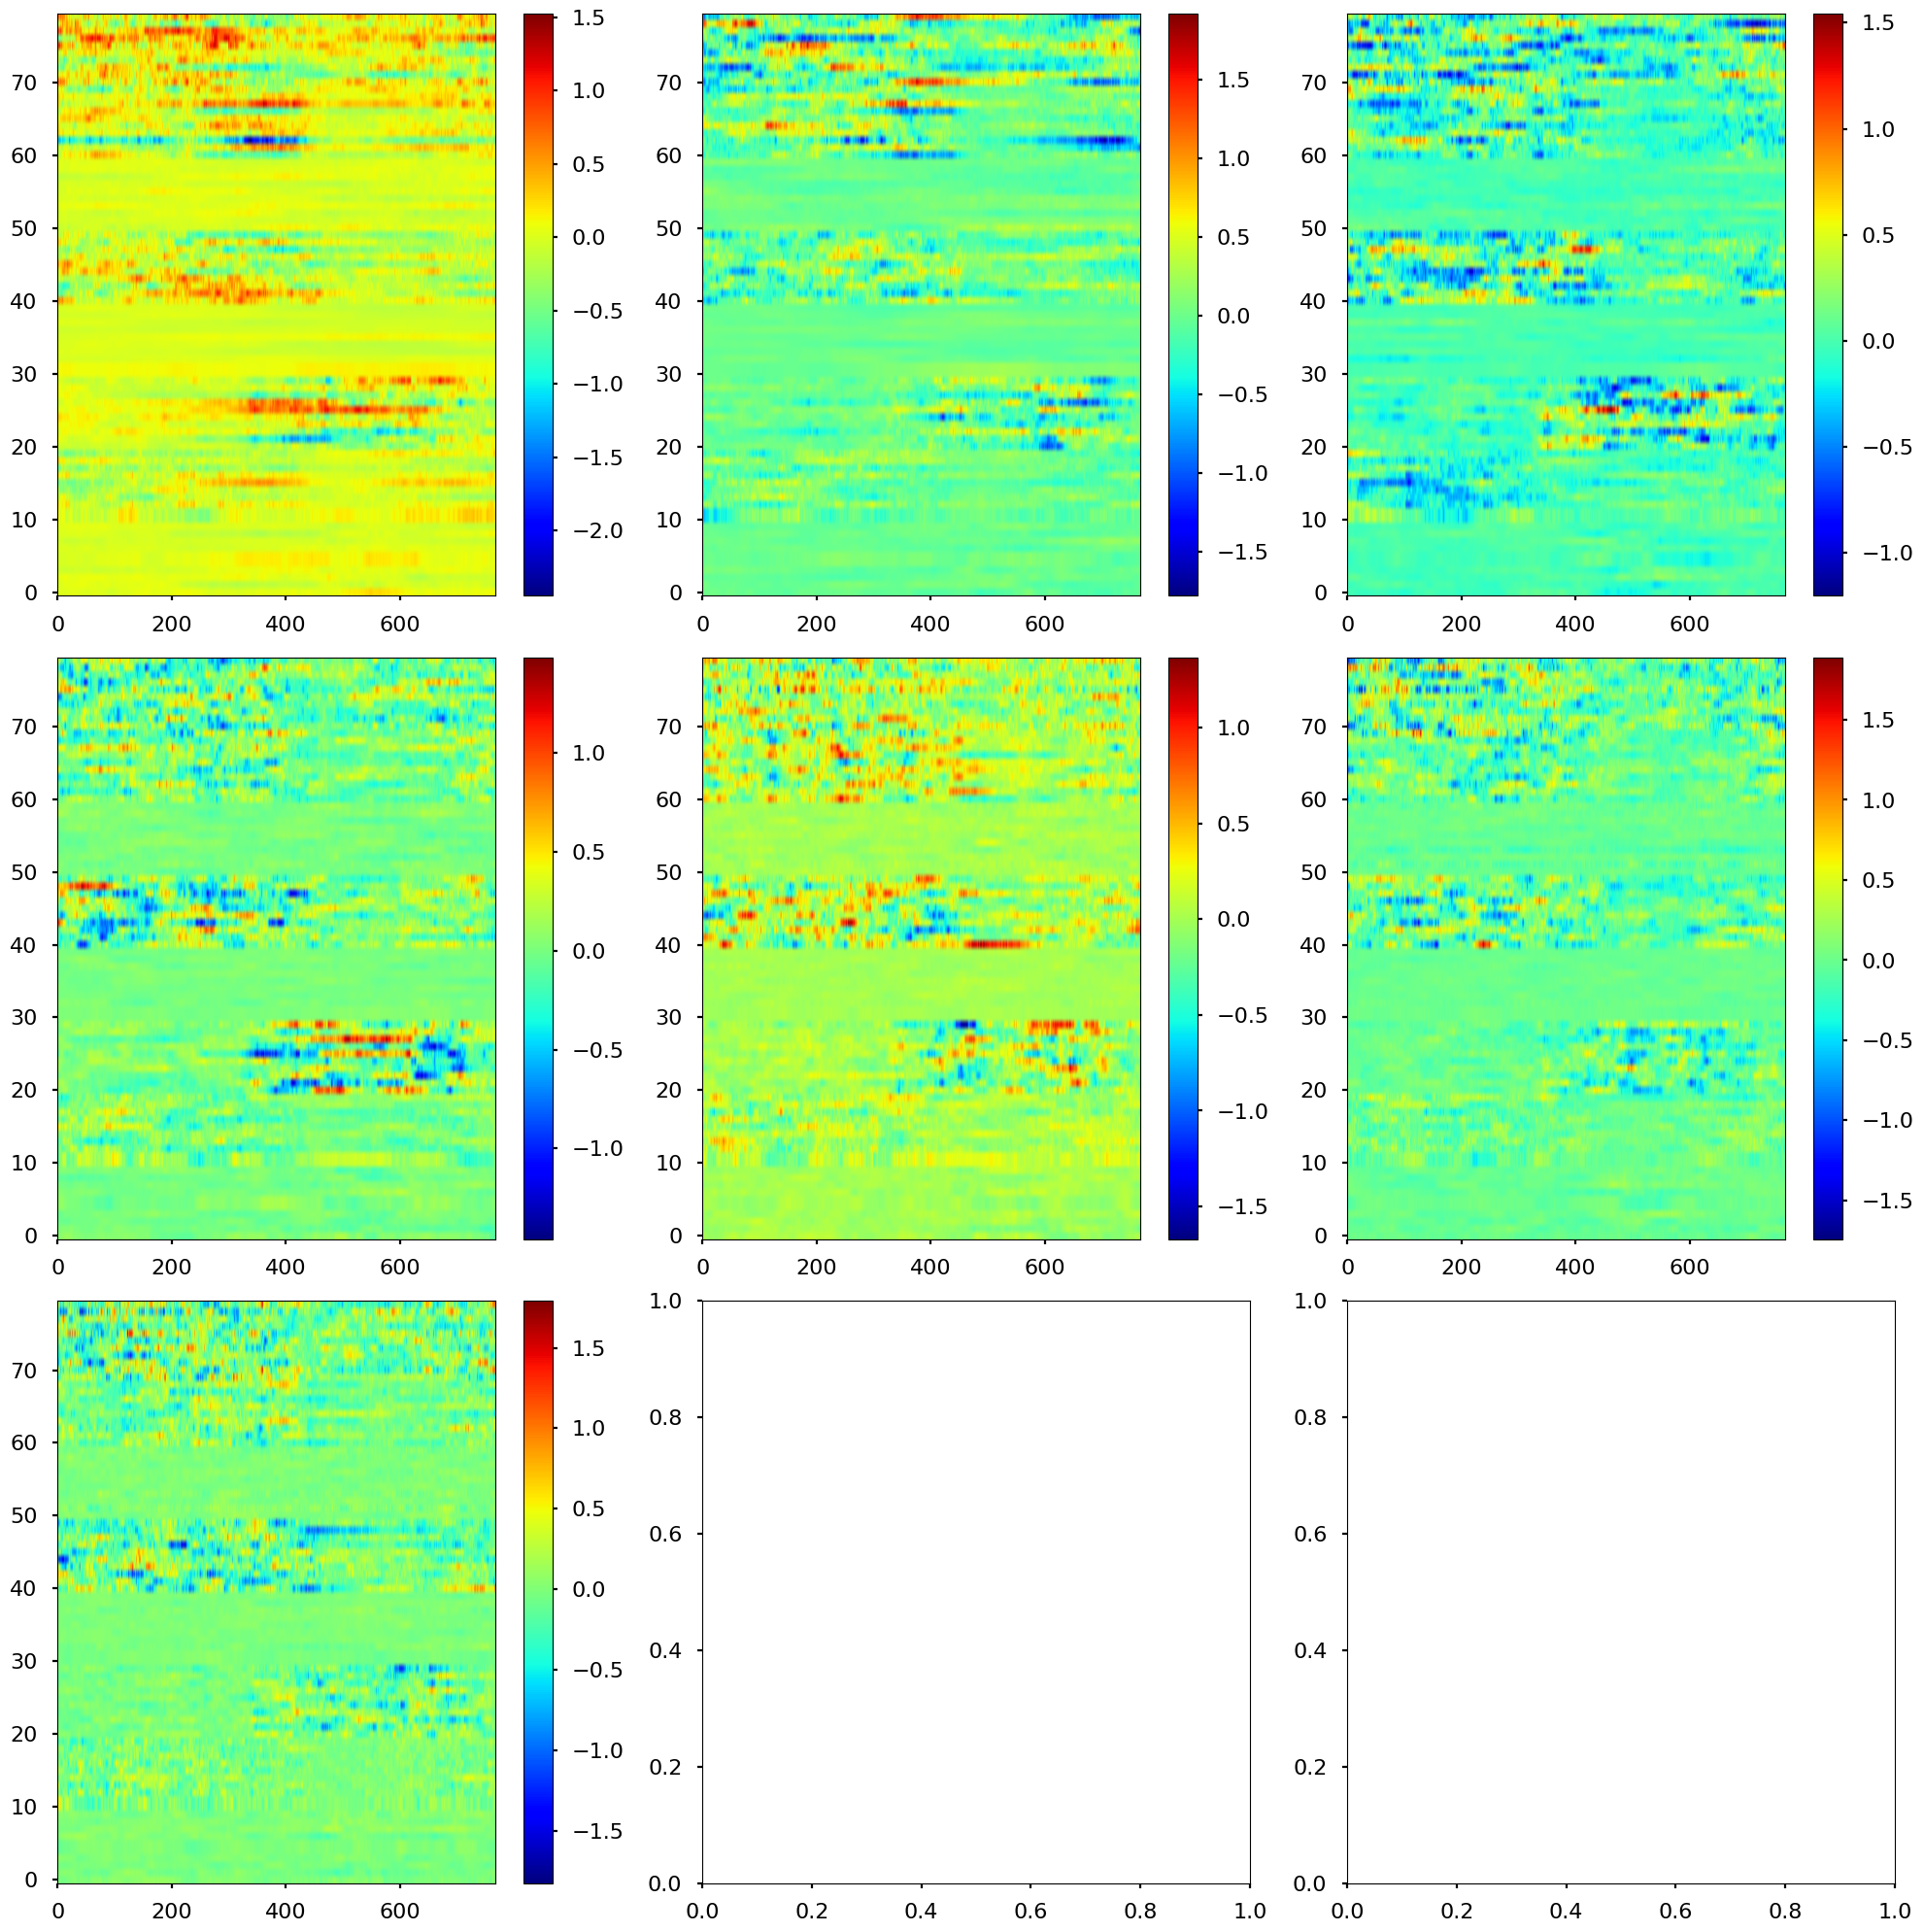

In [22]:
fig, axs = plt.subplots(3, 3, figsize = (20, 20))
axs = axs.flatten()
for i in range(n_frband):
    im = axs[i].imshow(beta_mat[i, best_channel_df["chan_idx_global"].values], aspect = 'auto', origin = "lower", cmap = 'jet')
    plt.colorbar(im, ax = axs[i])
plt.tight_layout()